In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("../data/Dataset.txt", sep="\t")
data.head()

,Age recode with <1 year olds and 90+,Sex,Year of diagnosis,"Race recode (W, B, AI, API)",Primary Site - labeled,Summary stage 2000 (1998-2017),Survival months,Vital status recode (study cutoff used),Median household income inflation adj to 2024
0,15-19 years,Male,2016,White,"C71.9-Brain, NOS",Localized,0091,Alive,"$110,000 - $119,999"
1,15-19 years,Male,2015,White,C71.2-Temporal lobe,Localized,0101,Alive,"$100,000 - $109,999"
2,10-14 years,Female,2013,White,C22.0-Liver,Regional,0122,Alive,"$100,000 - $109,999"
3,10-14 years,Male,2013,White,C73.9-Thyroid gland,Regional,0129,Alive,"$100,000 - $109,999"
4,15-19 years,Female,2021,White,C73.9-Thyroid gland,Blank(s),0031,Alive,"$120,000+"


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50603 entries, 0 to 50602
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   Age recode with <1 year olds and 90+           50603 non-null  str  
 1   Sex                                            50603 non-null  str  
 2   Year of diagnosis                              50603 non-null  int64
 3   Race recode (W, B, AI, API)                    50603 non-null  str  
 4   Primary Site - labeled                         50603 non-null  str  
 5   Summary stage 2000 (1998-2017)                 50603 non-null  str  
 6   Survival months                                50603 non-null  str  
 7   Vital status recode (study cutoff used)        50603 non-null  str  
 8   Median household income inflation adj to 2024  50603 non-null  str  
dtypes: int64(1), str(8)
memory usage: 3.5 MB


In [4]:
data.describe()

,Year of diagnosis
count,50603.000000
mean,2017.422564
std,3.423367
min,2012.000000
25%,2014.000000
50%,2017.000000
75%,2020.000000
max,2023.000000


In [5]:
data.shape

(50603, 9)

In [6]:
# Identificar valores nulos
print("Valores nulos en el dataset:")
print(data.isnull().sum())

# Identificar cantidad de duplicados
print(f"\nCantidad de filas duplicadas: {data.duplicated().sum()}")

Valores nulos en el dataset:
Age recode with <1 year olds and 90+             0
Sex                                              0
Year of diagnosis                                0
Race recode (W, B, AI, API)                      0
Primary Site - labeled                           0
Summary stage 2000 (1998-2017)                   0
Survival months                                  0
Vital status recode (study cutoff used)          0
Median household income inflation adj to 2024    0
dtype: int64

Cantidad de filas duplicadas: 3435


In [7]:
data.columns = [
    "Age", "Sex", "Year", "Race", "Cancer_Type",
    "Stage", "Survival_Months", "Vital_Status", "Income"
]

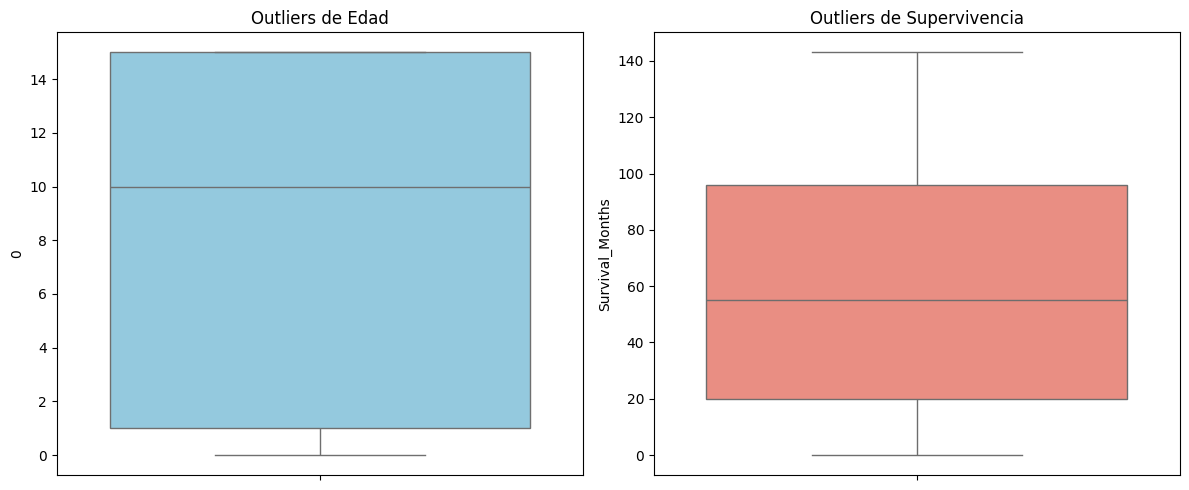

In [8]:
# Corrección del diagnóstico de calidad para el Eje Clínico
data["Survival_Months"] = pd.to_numeric(data["Survival_Months"], errors="coerce")

plt.figure(figsize=(12, 5))

# Subplot 1: Outliers de Edad
plt.subplot(1, 2, 1)
edad_numerica = data["Age"].str.extract(r'(\d+)')[0].astype(float)
sns.boxplot(y=edad_numerica, color="skyblue")
plt.title("Outliers de Edad")

# Subplot 2: Outliers de Supervivencia
plt.subplot(1, 2, 2)
sns.boxplot(y=data["Survival_Months"], color="salmon")
plt.title("Outliers de Supervivencia")

plt.tight_layout()
plt.show()

In [9]:
data = data[data["Stage"] != "Blank(s)"]
data = data.dropna()
data["Income"] = data["Income"].str.replace("$", "", regex=False)

In [10]:
def asignar_prioridad(row):
    stage = row["Stage"]
    survival = row["Survival_Months"]
    vital = row["Vital_Status"]

    if stage == "Distant":
        return "Alta"
    elif vital == "Dead" and survival < 36:
        return "Alta"
    elif stage == "Regional" and survival < 60:
        return "Alta"

    elif stage == "Regional":
        return "Media"
    elif stage in ["Localized", "In situ"] and survival < 60:
        return "Media"
    elif stage == "Unknown/unstaged":
        return "Media"
    else:
        return "Baja"

data["Prioridad"] = data.apply(asignar_prioridad, axis=1)

In [11]:
data["Prioridad"].value_counts()

Prioridad
Baja     6653
Media    4104
Alta     4031
Name: count, dtype: int64

In [12]:
data["Prioridad"].value_counts(normalize=True) * 100

Prioridad
Baja     44.989180
Media    27.752232
Alta     27.258588
Name: proportion, dtype: float64

In [13]:
from scipy.stats import shapiro

print("\n--- PRUEBA DE NORMALIDAD (SHAPIRO-WILK) ---")
for col in ["Survival_Months"]:
    stat, p = shapiro(data[col].sample(5000))
    print(f"Variable {col}: p-valor = {p:.4f}")
    if p < 0.05:
        print(f"Interpretación: No es Normal (Se rechaza H0)")


--- PRUEBA DE NORMALIDAD (SHAPIRO-WILK) ---
Variable Survival_Months: p-valor = 0.0000
Interpretación: No es Normal (Se rechaza H0)


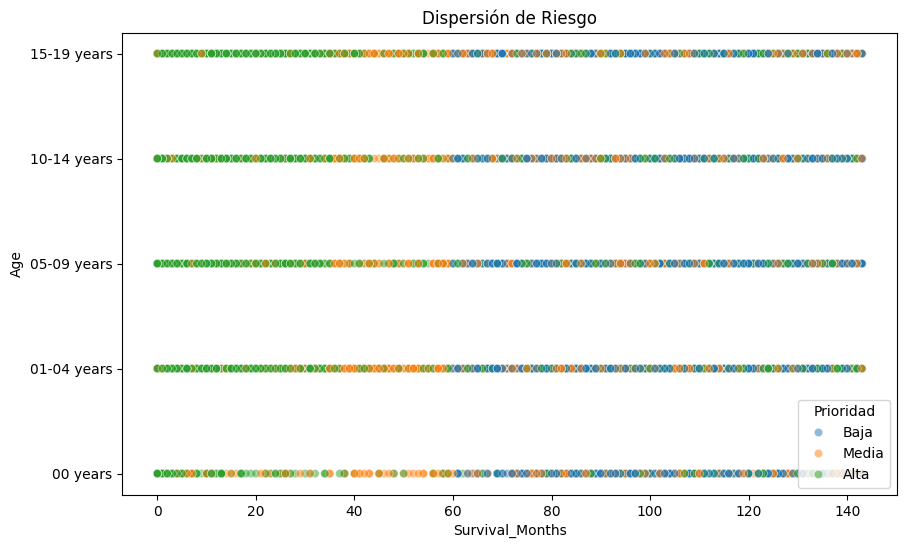

In [14]:
# Gráfico de Dispersión: Predictora vs Variable Objetivo
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x="Survival_Months", y="Age", hue="Prioridad", alpha=0.5)
plt.title("Dispersión de Riesgo")
plt.show()

In [15]:
data_corr = data.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in data_corr.select_dtypes(include='object').columns:
    data_corr[col] = le.fit_transform(data_corr[col])

C:\Users\cance\AppData\Local\Temp\ipykernel_9260\309981575.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data_corr.select_dtypes(include='object').columns:


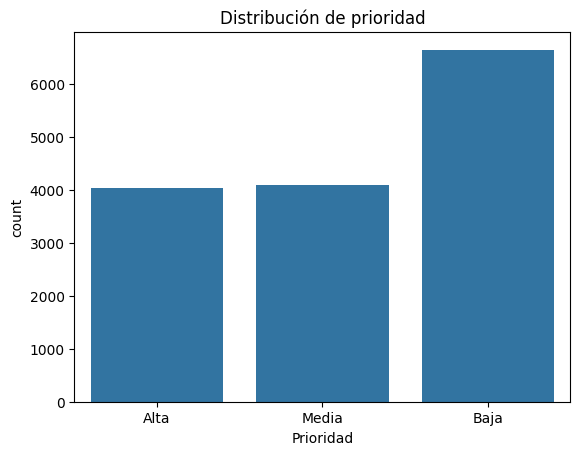

In [16]:
sns.countplot(data=data, x="Prioridad", order=["Alta", "Media", "Baja"])
plt.title("Distribución de prioridad")
plt.show()

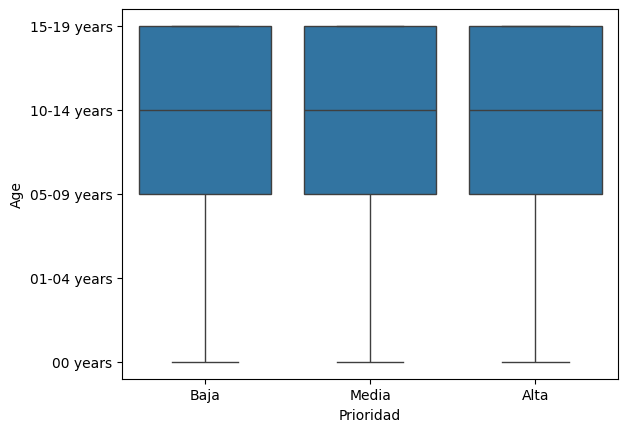

In [17]:
sns.boxplot(data=data, x="Prioridad", y="Age")
plt.show()

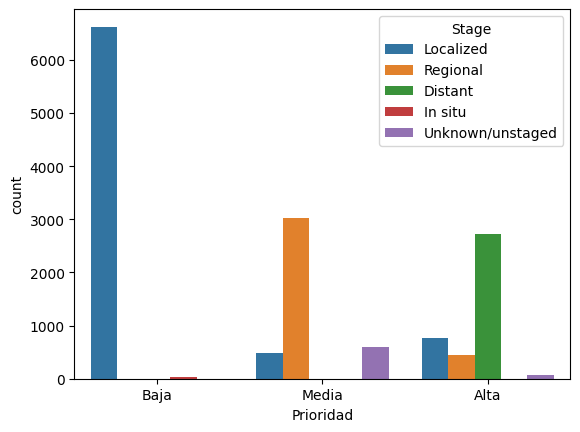

In [18]:
sns.countplot(data=data, x="Prioridad", hue="Stage")
plt.show()

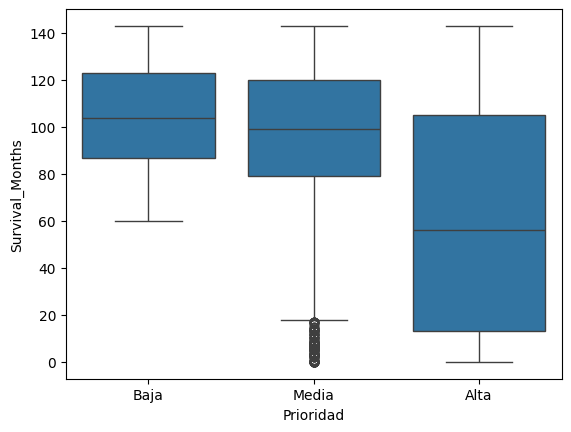

In [19]:
sns.boxplot(data=data, x="Prioridad", y="Survival_Months")
plt.show()

In [20]:
def agrupar_cancer(site):
    site = str(site)

    if "brain" in site.lower():
        return "Brain"
    elif "lung" in site.lower():
        return "Lung"
    elif "breast" in site.lower():
        return "Breast"
    elif "liver" in site.lower():
        return "Liver"
    elif "skin" in site.lower():
        return "Skin"
    elif "colon" in site.lower() or "rectum" in site.lower():
        return "Colorectal"
    else:
        return "Other"

data["Cancer_Group"] = data["Cancer_Type"].apply(agrupar_cancer)

In [21]:
data["Cancer_Type"] = data["Cancer_Type"].str.strip().str.lower()

In [22]:
data["Cancer_Type"].value_counts().head(20)

Cancer_Type
c73.9-thyroid gland                                           1454
c77.8-lymph nodes of multiple regions                         1295
c71.6-cerebellum, nos                                         1022
c64.9-kidney, nos                                              948
c71.7-brain stem                                               769
c77.0-lymph nodes of head, face & neck                         533
c62.1-descended testis                                         466
c18.1-appendix                                                 450
c71.9-brain, nos                                               443
c56.9-ovary                                                    439
c77.9-lymph node, nos                                          437
c22.0-liver                                                    406
c72.3-optic nerve                                              390
c62.9-testis, nos                                              344
c71.0-cerebrum                                    

In [23]:
top = data["Cancer_Type"].value_counts().head(10).index
data["Cancer_Group"] = data["Cancer_Type"].apply(
    lambda x: x if x in top else "Other"
)

print(top)

Index(['c73.9-thyroid gland', 'c77.8-lymph nodes of multiple regions',
       'c71.6-cerebellum, nos', 'c64.9-kidney, nos', 'c71.7-brain stem',
       'c77.0-lymph nodes of head, face & neck', 'c62.1-descended testis',
       'c18.1-appendix', 'c71.9-brain, nos', 'c56.9-ovary'],
      dtype='str', name='Cancer_Type')


In [24]:
X = data.drop(columns=["Prioridad", "Survival_Months", "Vital_Status"])
y = data["Prioridad"]

In [25]:
from sklearn.preprocessing import LabelEncoder

data_corr = data.copy()

le = LabelEncoder()

for col in data_corr.select_dtypes(include='object').columns:
    data_corr[col] = le.fit_transform(data_corr[col])

C:\Users\cance\AppData\Local\Temp\ipykernel_9260\4280875758.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data_corr.select_dtypes(include='object').columns:


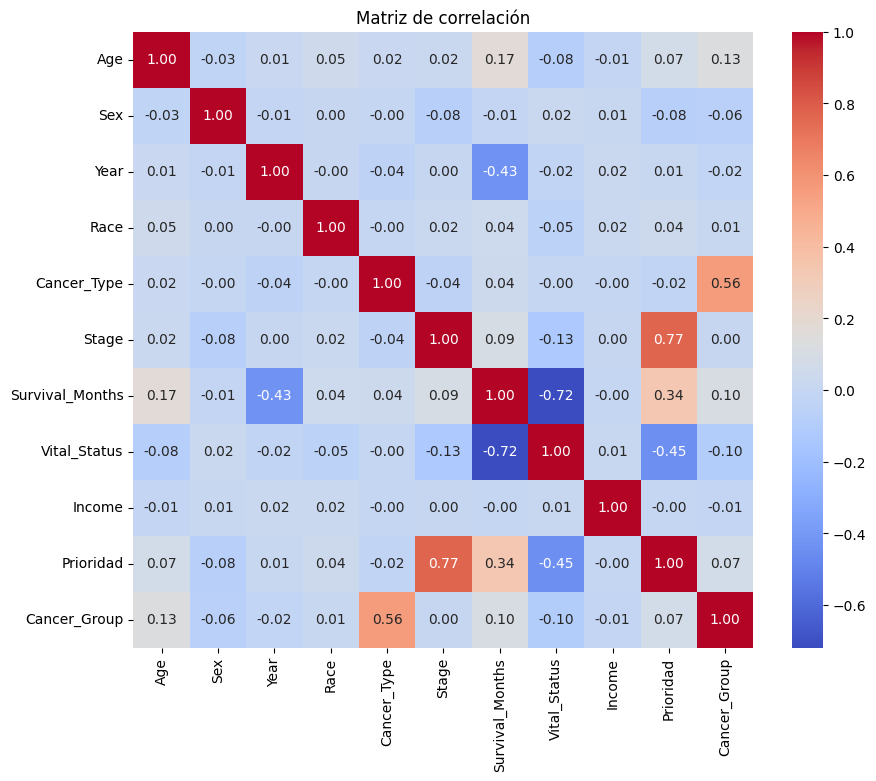

In [26]:
corr = data_corr.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

In [27]:
pd.crosstab(data["Stage"], data["Prioridad"], normalize="index")

Prioridad,Alta,Baja,Media
Stage,,,
Distant,1.000000,0.000000,0.000000
In situ,0.000000,0.965517,0.034483
Localized,0.098363,0.840843,0.060795
Regional,0.128139,0.000000,0.871861
Unknown/unstaged,0.115836,0.000000,0.884164


<Axes: xlabel='Prioridad', ylabel='Stage'>

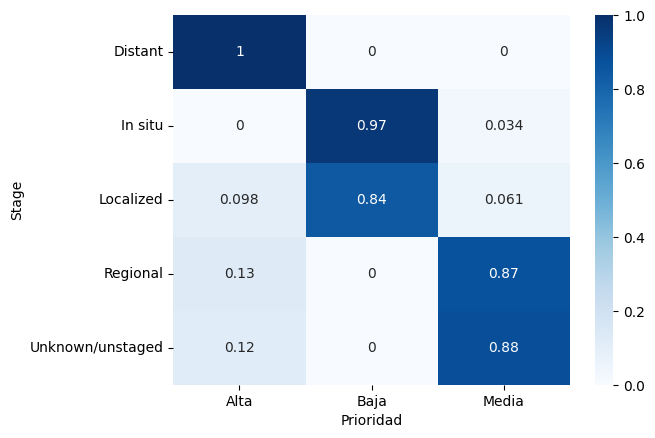

In [28]:
sns.heatmap(pd.crosstab(data["Stage"], data["Prioridad"], normalize="index"),
            annot=True, cmap="Blues")